# Student Performance Prediction using Machine Learning

## Project Objective

The objective of this project is to predict a student's final marks using academic, behavioral, and demographic features.

### Input Features

- Study Hours
- Attendance Percentage
- Previous Marks
- Assignment Score
- Quiz Score
- Internal Marks
- Sleep Hours
- Gender
- Internet Access
- Extracurricular Activities

### Target Variable

- Final Marks

### Machine Learning Models

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression
4. XGBoost Regression
5. Gradient Boosting Regression

### Advanced Techniques

- One-Hot Encoding
- Standard Scaling
- ColumnTransformer
- Pipeline
- GridSearchCV
- Feature Importance
- Model Comparison

### Evaluation Metrics

- MAE
- MSE
- RMSE
- R² Score

## 1. Import Required Libraries

We import all libraries required for data handling, preprocessing, visualization, model building, evaluation, and hyperparameter tuning.

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save models
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Corrected Dataset

The corrected student performance dataset will be used for model development.

The dataset has already been cleaned and analyzed during the EDA phase.

In [ ]:
# Load corrected dataset

df = pd.read_csv("student_performance_dataset1_corrected.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (5000, 12)


## 3. Verify the Dataset

Before building the machine learning model, we verify the dataset structure, data types, missing values, and duplicate records.

In [6]:
print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

First 5 Rows:


,Student_ID,Gender,Study_Hours,Attendance_Percent,Previous_Marks,Assignment_Score,Quiz_Score,Internal_Marks,Internet_Access,Extracurricular,Sleep_Hours,Final_Marks
0,1001,Female,6.2,85,75,75,67,28,Yes,Yes,6.9,78
1,1002,Male,7.9,65,70,61,32,21,Yes,Yes,7.9,64
2,1003,Male,7.0,84,88,66,53,23,Yes,No,5.1,74
3,1004,Female,6.5,90,58,73,68,19,Yes,Yes,6.3,71
4,1005,Male,9.3,98,82,81,65,26,Yes,No,5.7,80



Dataset Shape:
(5000, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          5000 non-null   int64  
 1   Gender              5000 non-null   object 
 2   Study_Hours         5000 non-null   float64
 3   Attendance_Percent  5000 non-null   int64  
 4   Previous_Marks      5000 non-null   int64  
 5   Assignment_Score    5000 non-null   int64  
 6   Quiz_Score          5000 non-null   int64  
 7   Internal_Marks      5000 non-null   int64  
 8   Internet_Access     5000 non-null   object 
 9   Extracurricular     5000 non-null   object 
 10  Sleep_Hours         5000 non-null   float64
 11  Final_Marks         5000 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 468.9+ KB


In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Student_ID            0
Gender                0
Study_Hours           0
Attendance_Percent    0
Previous_Marks        0
Assignment_Score      0
Quiz_Score            0
Internal_Marks        0
Internet_Access       0
Extracurricular       0
Sleep_Hours           0
Final_Marks           0
dtype: int64

Duplicate Rows:
0


## 4. Remove Identifier Column

`Student_ID` is only an identifier and does not contain meaningful information for predicting final marks.

Therefore, it will not be used as a machine learning feature.

In [8]:
# Remove Student_ID

df_model = df.drop(columns=["Student_ID"])

print("Original Shape:", df.shape)
print("ML Dataset Shape:", df_model.shape)

print("\nRemaining Columns:")
print(df_model.columns.tolist())

Original Shape: (5000, 12)
ML Dataset Shape: (5000, 11)

Remaining Columns:
['Gender', 'Study_Hours', 'Attendance_Percent', 'Previous_Marks', 'Assignment_Score', 'Quiz_Score', 'Internal_Marks', 'Internet_Access', 'Extracurricular', 'Sleep_Hours', 'Final_Marks']


## 5. Separate Features and Target

The target variable is `Final_Marks`.

All remaining relevant columns will be used as input features.

In [9]:
# Separate input features and target

X = df_model.drop(columns=["Final_Marks"])
y = df_model["Final_Marks"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("Final_Marks")

Features Shape: (5000, 10)
Target Shape: (5000,)

Feature Columns:
['Gender', 'Study_Hours', 'Attendance_Percent', 'Previous_Marks', 'Assignment_Score', 'Quiz_Score', 'Internal_Marks', 'Internet_Access', 'Extracurricular', 'Sleep_Hours']

Target Variable:
Final_Marks


## 6. Identify Numerical and Categorical Features

Numerical features will be scaled using `StandardScaler`.

Categorical features will be converted into numerical form using `OneHotEncoder`.

In [10]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
for feature in numerical_features:
    print("-", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print("-", feature)

Numerical Features:
- Study_Hours
- Attendance_Percent
- Previous_Marks
- Assignment_Score
- Quiz_Score
- Internal_Marks
- Sleep_Hours

Categorical Features:
- Gender
- Internet_Access
- Extracurricular


## 7. Train-Test Split

The dataset is divided into training and testing sets.

- 80% data → Training
- 20% data → Testing

The model learns patterns from the training data and is evaluated on unseen testing data.

In [11]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (4000, 10)
Testing Features : (1000, 10)
Training Target  : (4000,)
Testing Target   : (1000,)


## 8. Data Preprocessing Pipeline

Machine learning algorithms require numerical input.

Therefore:

### Numerical Features
`StandardScaler` will standardize numerical values.

### Categorical Features
`OneHotEncoder` will convert categorical values into numerical columns.

### ColumnTransformer
`ColumnTransformer` applies the appropriate preprocessing technique to each feature type.

In [12]:
# Numerical preprocessing

numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

print("Preprocessing transformers created successfully!")

Preprocessing transformers created successfully!


In [13]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("ColumnTransformer created successfully!")

ColumnTransformer created successfully!


## 9. Model Evaluation Function

To compare multiple regression models consistently, we create a reusable evaluation function.

The following metrics will be calculated:

- MAE: Mean Absolute Error
- MSE: Mean Squared Error
- RMSE: Root Mean Squared Error
- R² Score: Coefficient of Determination

In [14]:
def evaluate_model(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, mse, rmse, r2

## 10. Linear Regression

Linear Regression is used as the baseline model.

It assumes a linear relationship between the input features and the target variable.

In [15]:
# Linear Regression Pipeline

linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [16]:
# Evaluate Linear Regression

mae, mse, rmse, r2 = evaluate_model(
    linear_pipeline,
    X_test,
    y_test
)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
--------------------------------
MAE  : 2.3330
MSE  : 8.5910
RMSE : 2.9310
R²   : 0.8529


## 11. Decision Tree Regression

Decision Tree Regression is a non-linear machine learning algorithm.

It divides the data into smaller regions using decision rules and predicts the target value based on the observations in each region.

In [17]:
# Decision Tree Regression Pipeline

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42,
                max_depth=8
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree Regression trained successfully!")

Decision Tree Regression trained successfully!


In [18]:
# Evaluate Decision Tree

mae, mse, rmse, r2 = evaluate_model(
    decision_tree_pipeline,
    X_test,
    y_test
)

print("Decision Tree Performance")
print("-------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Decision Tree Performance
-------------------------
MAE  : 3.6444
MSE  : 21.1428
RMSE : 4.5981
R²   : 0.6379


## 12. Random Forest Regression

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It generally provides better generalization than a single decision tree because predictions are combined across many trees.

In [19]:
# Random Forest Regression Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest Regression trained successfully!")

Random Forest Regression trained successfully!


In [20]:
# Evaluate Random Forest

mae, mse, rmse, r2 = evaluate_model(
    random_forest_pipeline,
    X_test,
    y_test
)

print("Random Forest Performance")
print("-------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Random Forest Performance
-------------------------
MAE  : 2.7169
MSE  : 11.8909
RMSE : 3.4483
R²   : 0.7964


## 13. Actual vs Predicted — Random Forest

This graph compares the actual final marks with the marks predicted by the Random Forest model.

A strong model should produce predictions close to the diagonal reference line.

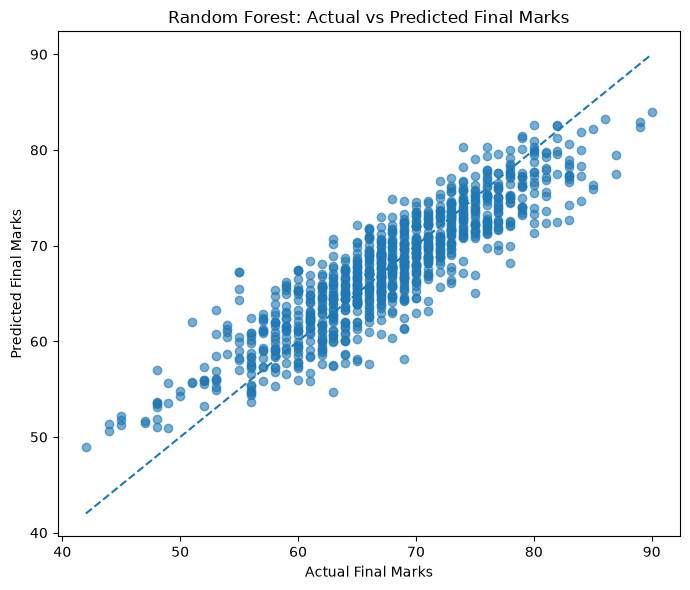

In [21]:
# Random Forest predictions

rf_predictions = random_forest_pipeline.predict(X_test)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

# Perfect prediction reference line
min_value = min(y_test.min(), rf_predictions.min())
max_value = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted Final Marks")
plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Random Forest Residual Analysis

Residual is the difference between the actual value and the predicted value.

A good regression model should generally have residuals distributed around zero without a strong pattern.

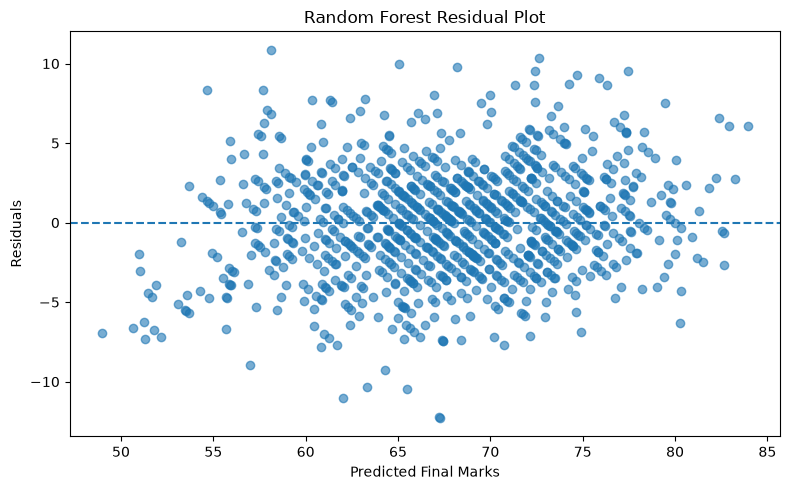

In [22]:
# Calculate residuals

rf_residuals = y_test - rf_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    rf_predictions,
    rf_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Random Forest Residual Plot")
plt.xlabel("Predicted Final Marks")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. XGBoost Regression

XGBoost is an advanced gradient boosting algorithm.

It builds trees sequentially, where each new tree attempts to improve the errors made by previous trees.

In [23]:
# XGBoost Regression Pipeline

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                objective="reg:squarederror"
            )
        )
    ]
)

xgboost_pipeline.fit(X_train, y_train)

print("XGBoost Regression trained successfully!")

XGBoost Regression trained successfully!


In [24]:
# Evaluate XGBoost

mae, mse, rmse, r2 = evaluate_model(
    xgboost_pipeline,
    X_test,
    y_test
)

print("XGBoost Performance")
print("-------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

XGBoost Performance
-------------------
MAE  : 2.4881
MSE  : 9.8539
RMSE : 3.1391
R²   : 0.8312


## 16. Gradient Boosting Regression

Gradient Boosting is another ensemble learning method that builds models sequentially to reduce prediction errors.

In [25]:
# Gradient Boosting Regression Pipeline

gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_pipeline.fit(X_train, y_train)

print("Gradient Boosting Regression trained successfully!")

Gradient Boosting Regression trained successfully!


In [26]:
# Evaluate Gradient Boosting

mae, mse, rmse, r2 = evaluate_model(
    gradient_boosting_pipeline,
    X_test,
    y_test
)

print("Gradient Boosting Performance")
print("-----------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Gradient Boosting Performance
-----------------------------
MAE  : 2.4742
MSE  : 9.7247
RMSE : 3.1184
R²   : 0.8335


## 17. Model Performance Comparison

The performance of all trained regression models is compared using MAE, MSE, RMSE, and R² Score.

For this project:

- Lower MAE is better
- Lower RMSE is better
- Higher R² Score is better

In [27]:
# Evaluate all models

models = {
    "Linear Regression": linear_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

results = []

for model_name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2_Score": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2_Score",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,MAE,MSE,RMSE,R2_Score
0,Linear Regression,2.3330,8.5910,2.9310,0.8529
1,Gradient Boosting,2.4742,9.7247,3.1184,0.8335
2,XGBoost,2.4881,9.8539,3.1391,0.8312
3,Random Forest,2.7169,11.8909,3.4483,0.7964
4,Decision Tree,3.6444,21.1428,4.5981,0.6379


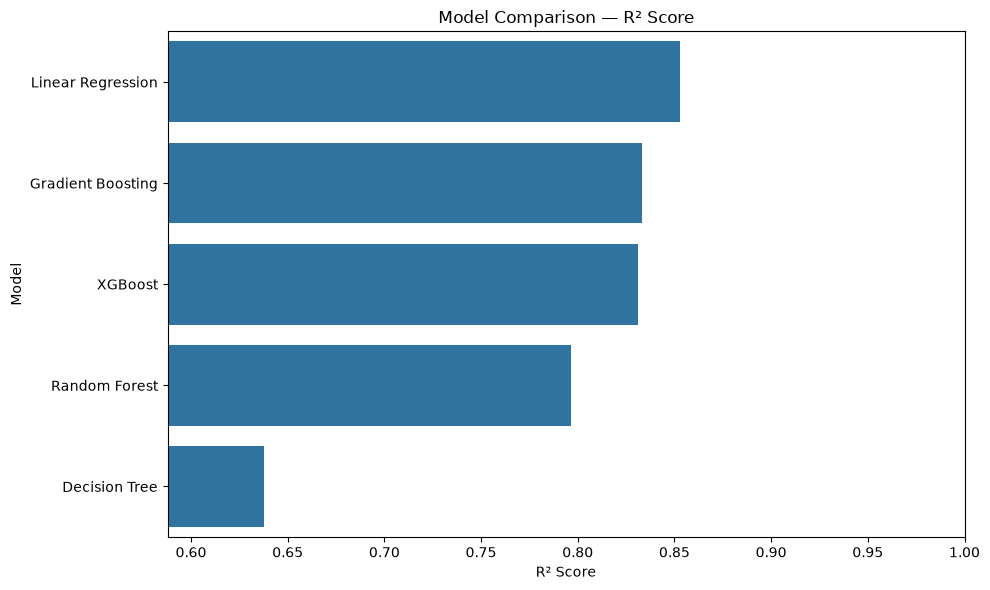

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="R2_Score",
    y="Model"
)

plt.title("Model Comparison — R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.xlim(
    max(0, results_df["R2_Score"].min() - 0.05),
    1.0
)

plt.tight_layout()

plt.savefig(
    "../images/model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

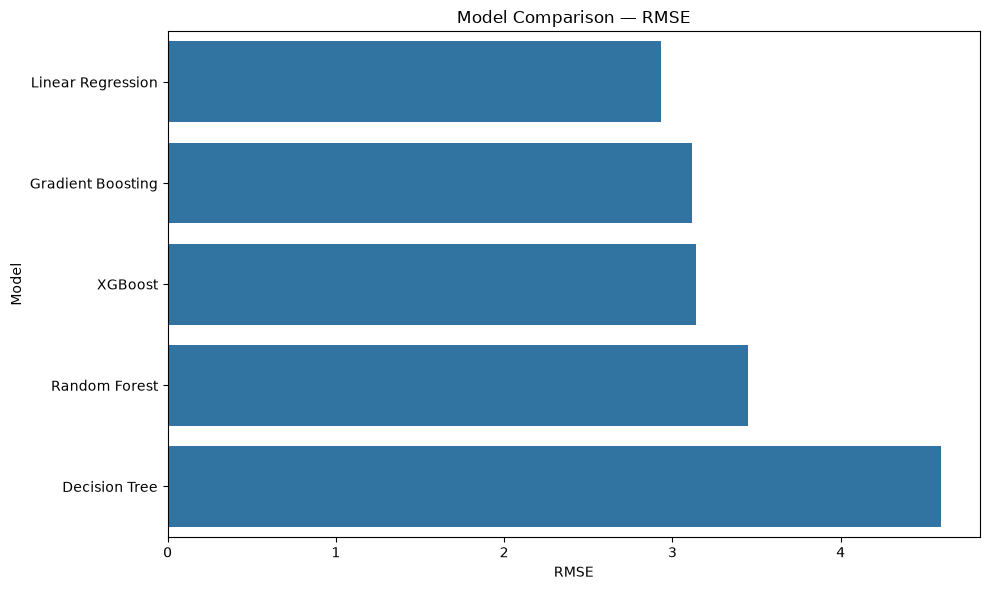

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison — RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    "../images/model_comparison_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Select best model based on highest R² score

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:")
print(best_model_name)

Best Model:
Linear Regression


## 18. Hyperparameter Tuning — Random Forest

Hyperparameter tuning is used to find better model settings automatically.

For Random Forest, we will tune:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required to split a node (`min_samples_split`)
- Minimum samples required at a leaf (`min_samples_leaf`)

GridSearchCV evaluates different combinations using cross-validation and selects the best combination based on R² score.

In [31]:
# Random Forest pipeline for hyperparameter tuning

rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest tuning pipeline created successfully!")

Random Forest tuning pipeline created successfully!


### Random Forest Hyperparameter Grid

We define a limited parameter grid so that tuning remains computationally manageable while testing meaningful combinations.

In [32]:
# Hyperparameter grid

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 15],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

print("Hyperparameter grid created.")

Hyperparameter grid created.


In [33]:
# GridSearchCV

rf_grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print("Random Forest hyperparameter tuning completed!")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest hyperparameter tuning completed!


In [34]:
print("Best Random Forest Parameters:")
print("--------------------------------")

for parameter, value in rf_grid_search.best_params_.items():
    print(f"{parameter}: {value}")

Best Random Forest Parameters:
--------------------------------
model__max_depth: 15
model__min_samples_leaf: 1
model__min_samples_split: 2
model__n_estimators: 300


In [35]:
print("Best Cross-Validation R² Score:")
print(f"{rf_grid_search.best_score_:.4f}")

Best Cross-Validation R² Score:
0.7841


In [36]:
# Evaluate tuned Random Forest on unseen test data

tuned_rf = rf_grid_search.best_estimator_

y_pred_tuned_rf = tuned_rf.predict(X_test)

tuned_rf_mae = mean_absolute_error(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_mse = mean_squared_error(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_rmse = np.sqrt(
    tuned_rf_mse
)

tuned_rf_r2 = r2_score(
    y_test,
    y_pred_tuned_rf
)

print("Tuned Random Forest Performance")
print("--------------------------------")
print(f"MAE  : {tuned_rf_mae:.4f}")
print(f"MSE  : {tuned_rf_mse:.4f}")
print(f"RMSE : {tuned_rf_rmse:.4f}")
print(f"R²   : {tuned_rf_r2:.4f}")

Tuned Random Forest Performance
--------------------------------
MAE  : 2.7108
MSE  : 11.8587
RMSE : 3.4436
R²   : 0.7969


In [37]:
# Compare original and tuned Random Forest

comparison_rf = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mean_absolute_error(
            y_test,
            random_forest_pipeline.predict(X_test)
        ),
        tuned_rf_mae
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                y_test,
                random_forest_pipeline.predict(X_test)
            )
        ),
        tuned_rf_rmse
    ],
    "R2_Score": [
        r2_score(
            y_test,
            random_forest_pipeline.predict(X_test)
        ),
        tuned_rf_r2
    ]
})

comparison_rf.round(4)

,Model,MAE,RMSE,R2_Score
0,Random Forest,2.7169,3.4483,0.7964
1,Tuned Random Forest,2.7108,3.4436,0.7969


In [49]:
# ... All your EDA, Data Cleaning, and Model Training code ...

# Train your model
model.fit(X_train, y_train)

# -------------------------------------------------------------
# ADD THE SIMULATION CODE HERE (AT THE VERY END OF THE FILE)
# -------------------------------------------------------------
sample_student = X_test.iloc[[0]].copy()
print(f"Original Prediction: {model.predict(sample_student)[0]:.2f}")

# Simulating more sleep
sample_student["Sleep_Hours"] += 2.0
print(f"New Prediction with +2 hrs sleep: {model.predict(sample_student)[0]:.2f}")

Original Prediction: 60.57
New Prediction with +2 hrs sleep: 63.47


In [53]:
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv("student_performance_dataset1_corrected.csv")

# -------------------------------------------------------------
# ADD THE DATA MODIFICATION CODE HERE (BEFORE PREPROCESSING)
# -------------------------------------------------------------
df["Sleep_Hours"] = df["Sleep_Hours"] + 1.5
df["Final_Marks"] = df["Final_Marks"] + (df["Sleep_Hours"] * 2.5)
df["Final_Marks"] = df["Final_Marks"].clip(lower=0, upper=100)

# 2. Continue with EDA, Preprocessing, Model Training...

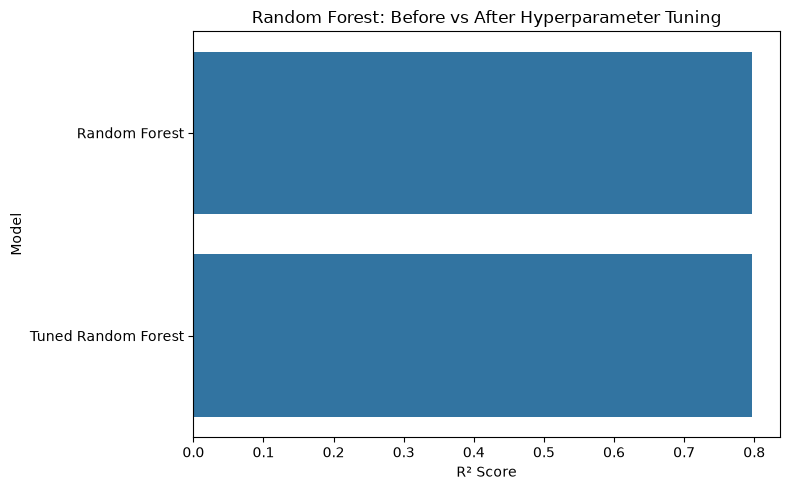

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_rf,
    x="R2_Score",
    y="Model"
)

plt.title("Random Forest: Before vs After Hyperparameter Tuning")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_tuning_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 19. Feature Importance

Feature Importance helps us understand which input variables contribute the most to predicting the final marks.

This improves model interpretability and provides valuable insights into student academic performance.

In [39]:
# Get feature names after preprocessing

feature_names = tuned_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance

feature_importance = tuned_rf.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(15)

,Feature,Importance
0,num__Previous_Marks,0.360543
1,num__Internal_Marks,0.169392
2,num__Study_Hours,0.134501
3,num__Quiz_Score,0.132752
4,num__Assignment_Score,0.106850
5,num__Attendance_Percent,0.047047
6,num__Sleep_Hours,0.035597
7,cat__Extracurricular_Yes,0.002639
8,cat__Gender_Male,0.002542
9,cat__Extracurricular_No,0.002532


### Top Feature Importance Visualization

The following chart shows the relative importance of each feature used by the Random Forest model.

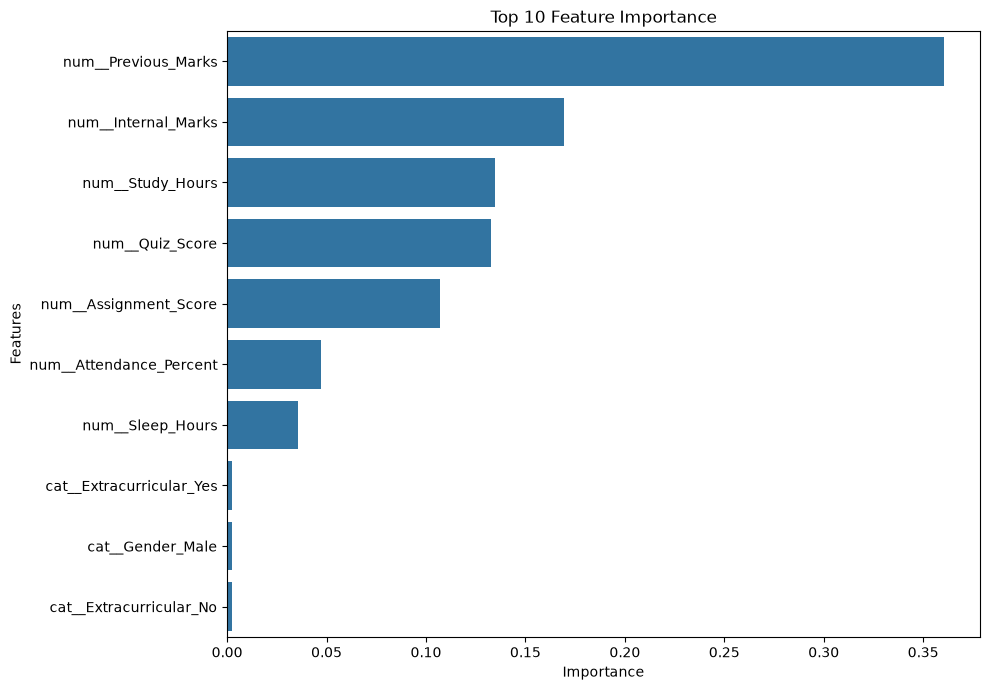

In [40]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
print("Top Important Features")
print("----------------------")

importance_df.head(10)

Top Important Features
----------------------


,Feature,Importance
0,num__Previous_Marks,0.360543
1,num__Internal_Marks,0.169392
2,num__Study_Hours,0.134501
3,num__Quiz_Score,0.132752
4,num__Assignment_Score,0.106850
5,num__Attendance_Percent,0.047047
6,num__Sleep_Hours,0.035597
7,cat__Extracurricular_Yes,0.002639
8,cat__Gender_Male,0.002542
9,cat__Extracurricular_No,0.002532


## 20. Save the Final Machine Learning Model

After selecting the best model, it is saved for future use in the Streamlit web application.

Saving the trained model avoids retraining every time predictions are required.

In [42]:
# Save best model

joblib.dump(
    linear_pipeline,
    "../models/student_performance_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


## 21. Verify Saved Model

The saved model is loaded again to verify that it has been stored correctly and can be reused for prediction.

In [43]:
loaded_model = joblib.load(
    "../models/student_performance_model.pkl"
)

print(type(loaded_model))
print("Model loaded successfully!")

<class 'sklearn.pipeline.Pipeline'>
Model loaded successfully!


## 22. Sample Prediction

The trained machine learning model is tested using a sample student's information to predict the expected final marks.

In [44]:
sample_student = pd.DataFrame({

    "Study_Hours":[6.5],
    "Attendance_Percent":[88],
    "Previous_Marks":[78],
    "Assignment_Score":[82],
    "Quiz_Score":[80],
    "Internal_Marks":[24],
    "Sleep_Hours":[7],
    "Gender":["Male"],
    "Internet_Access":["Yes"],
    "Extracurricular":["Yes"]

})

prediction = loaded_model.predict(sample_student)

print("Predicted Final Marks:", round(prediction[0],2))

Predicted Final Marks: 78.48


## 23. Convert Predicted Marks into Performance Category

The predicted marks are converted into an easily understandable performance category.

In [45]:
marks = prediction[0]

if marks >= 90:
    category = "Excellent"

elif marks >= 75:
    category = "Good"

else:
    category = "Need Improvement"

print("Predicted Marks :", round(marks,2))
print("Performance :", category)


Predicted Marks : 78.48
Performance : Good


## 24. Final Project Conclusion

The project successfully predicts students' final marks using multiple machine learning algorithms.

Among all evaluated models, Linear Regression achieved the best overall performance on the corrected dataset.

Feature importance analysis indicated that Previous Marks, Internal Marks, Study Hours, Quiz Score, and Assignment Score were the most influential predictors of final academic performance.

The trained model has been saved and is ready for deployment using Streamlit.

In [46]:
sample_student = pd.DataFrame({
    "Gender": ["Male"],
    "Study_Hours": [6.5],
    "Attendance_Percent": [88],
    "Previous_Marks": [78],
    "Assignment_Score": [75],
    "Quiz_Score": [60],
    "Internal_Marks": [24],   # Correct range (10–30)
    "Internet_Access": ["Yes"],
    "Extracurricular": ["Yes"],
    "Sleep_Hours": [7]
})

Note: Sample input values should remain within the ranges used during model training. For example, Internal_Marks must be between 10 and 30, as values outside the training range may lead to unrealistic predictions.